In [31]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm



In [32]:
C = Config()
C.gpu_id=1
C.seed = 1
C.linear_net = False
C.split_actions = False
C.learning_rate = 0.00001
C.algo_name = 'Adam'
C.L=8
C.G=0.8
C.hidden_size = 100
C.num_epochs *= 1
C.fixed_output = False
C.early_stopping = False
C.print_progress = True
C.loss_fn = nn.MSELoss()
C.num_corridors = 2
C.length_corridors = [30, 30]
C.max_move = 15
# C.num_epochs = 10000
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True
# C.max_move = 15

# C.min_move = 10
# C.one_hot_actions = False
# C.one_hot_inputs = False

In [33]:


X, y, corridor, loc_X, loc_y, action_taken, hidden_states, loss_l, accuracy_l, outputs, hidden_l, final_weights, initial_weights = run_sim(C)

hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
loc_y_corridor = loc_y + (corridor * max(loc_y + 1))

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
h_np = hidden  # Convert to numpy array if hidden is a torch tensor

 11%|█         | 1059/10000 [00:02<00:24, 359.35it/s]

Epoch 1000/10000, Loss: 0.0163


 21%|██        | 2062/10000 [00:05<00:22, 350.07it/s]

Epoch 2000/10000, Loss: 0.0156


 31%|███       | 3063/10000 [00:08<00:20, 340.07it/s]

...

Epoch 8000/10000, Loss: 0.0053


 91%|█████████ | 9052/10000 [00:25<00:02, 342.85it/s]

Epoch 9000/10000, Loss: 0.0039


100%|██████████| 10000/10000 [00:28<00:00, 347.63it/s]


Epoch 10000/10000, Loss: 0.0028


So far:

1. Ordering and alignment happen in a wide range of linear network hyper-parameters.
2. I haven't found the same with MSE loss, but likely and can be produced because it was seen in non-linear network.
3. Solutions are generally low-dim, but not necessarily. Performance still depends on many PCs.
4. One amazing detail is that only PC1 seems to be ordered and not the others, which raises the question why? Performance doesn't depend on it exclusively, so why would this very humanly appealing but network-wise senseless structure appear?
5. So far I haven't found linear relationship between action representations as hinted in Stefano's work, but there does seem to be some tuning of neurons to actions that is sometimes linear.
6. Another striking result is that the product of weights does not 100% match the input-output correlation matrix, but rather it has the added correlation that aligns corridors. This is in contrast to results from Saxe 2014, though of course not comparable because of the different loss function. That being said, it is strange to see that it is almost the same but with a very structured added component.
7. Can also see results in single hidden layer but they are less linear
8. How can hiddens have low PR and weights have high PR?

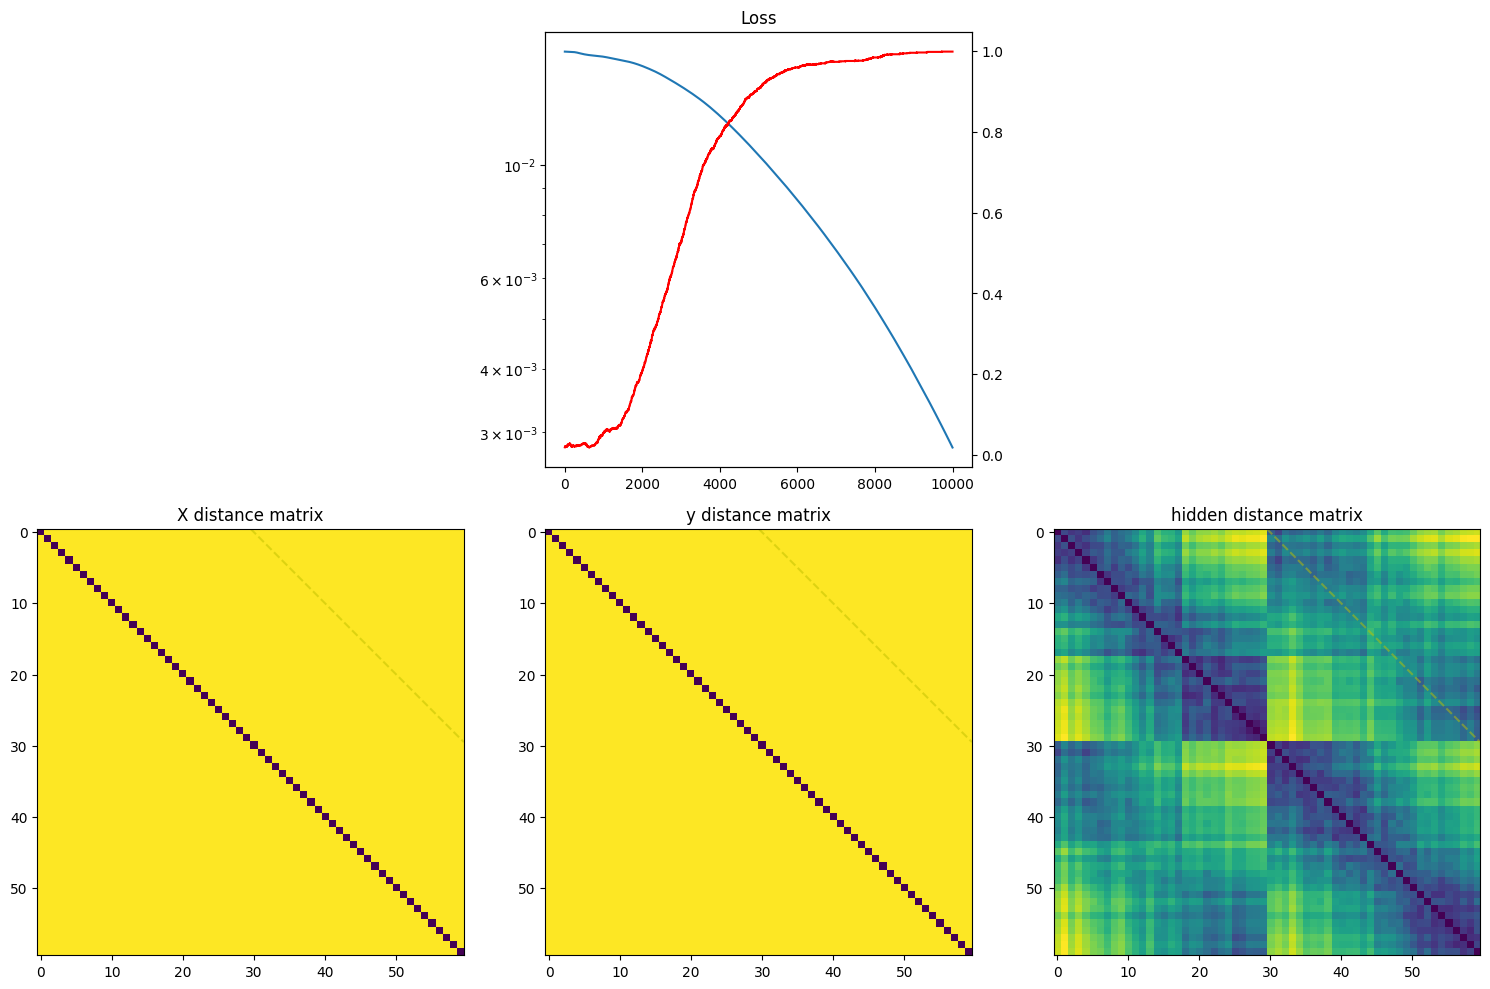

In [34]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    ax.imshow(var[stay_inds][:,stay_inds], cmap='viridis')
    ax.plot([len(stay_inds)//2-0.5, len(stay_inds)-0.5], [-0.5, len(stay_inds)//2-0.5], 'y--', alpha=0.5)
    ax.set_title(f'{var_name} distance matrix')
plt.tight_layout()
plt.show()

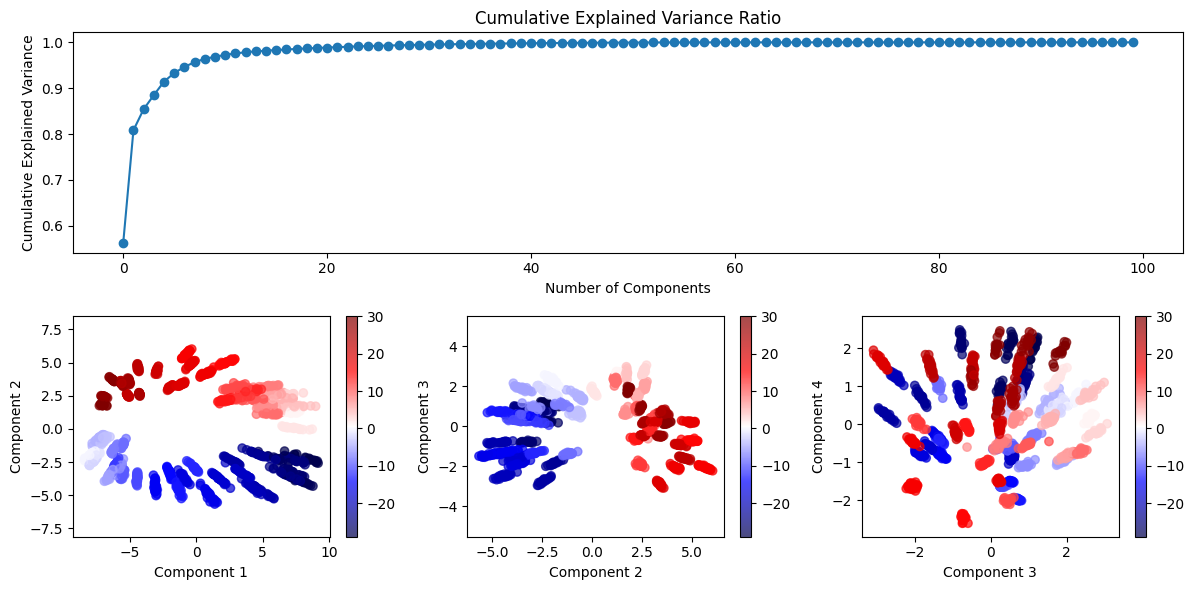

In [35]:
pca = PCA().fit(h_np)
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(12, 6))

# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('Cumulative Explained Variance Ratio')

# Add scatter plots in the second row
for i in range(3):
    ax = fig.add_subplot(2, 3, i + 4)
    c = (loc_y + (corridor * max(loc_y + 1)) - max(loc_y))
    # c = action_taken[inds]
    s = ax.scatter(X_reduced[:, i], X_reduced[:, i+1], c=c, cmap='seismic', alpha=0.7)
    ax.set_xlabel(f'Component {i+1}')
    ax.set_ylabel(f'Component {i+2}')
    ax.axis('equal')
    fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()

100%|██████████| 99/99 [00:08<00:00, 11.61it/s]


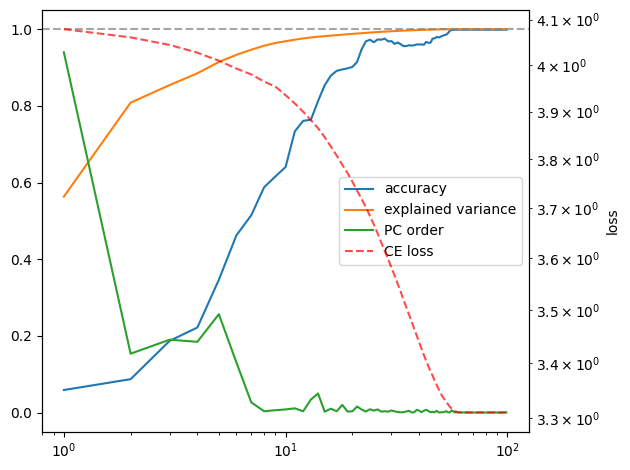

In [36]:

output_weights = final_weights['output_layer.weight'].cpu().detach().numpy()
pca1 = PCA().fit(hidden[corridor == 0])
pca2 = PCA().fit(hidden[corridor == 1])
pca = PCA().fit(hidden)
h_transformed = pca.transform(h_np)
h1_transformed = pca.transform(h_np[corridor == 0])
h2_transformed = pca.transform(h_np[corridor == 1])
pca_accuracy_l = []
pca_explained_var_l = []
pca_loss_l = []
order_l = []
n_pcs = np.arange(1, pca.components_.shape[0])
for n in tqdm(n_pcs):
    # h_reconstructed = pca.inverse_transform(h_transformed)
    h_reconstructed = h_transformed[:,:n] @ pca.components_[:n] + pca.mean_
    y_hat_pca = (h_reconstructed @ output_weights.T)
    # print(f'accuracy of first {n} PCs: {(y_hat_first_pc == y.argmax(1).cpu().detach().numpy()).mean()}')
    pca_accuracy_l.append((y_hat_pca.argmax(1) == y_np.argmax(1)).mean())
    pca_explained_var_l.append(pca.explained_variance_ratio_[:n].sum())
    pca_loss_l.append(nn.CrossEntropyLoss()(torch.tensor(y_hat_pca), y.cpu()).item())
    order1 = get_r_2(h1_transformed[:, [n-1]], loc_y[corridor == 0])
    order2 = get_r_2(h2_transformed[:, [n-1]], loc_y[corridor == 1])
    order_l.append((order1 + order2)/2)

fig, ax1 = plt.subplots()
plt.plot(n_pcs, pca_accuracy_l, label='accuracy')
plt.plot(n_pcs, pca_explained_var_l, label='explained variance')
plt.plot(n_pcs, order_l, label='PC order')
plt.axhline(1, color='gray', ls='--', alpha=0.7)
ax2 = ax1.twinx()
ax2.set_ylabel('loss')
ax2.plot(n_pcs, pca_loss_l, 'r', label='CE loss', ls='--', alpha=0.7)
ax2.set_yscale('log')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
plt.xlabel('number of PCs')
plt.xscale('log')
plt.tight_layout()
plt.show()